In [1]:
import sys

project_path = '/content/drive/MyDrive/credit_score_project'

if project_path not in sys.path:
    sys.path.append(project_path)

In [2]:
import kagglehub
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import my_module.custom_transformers as cst
import joblib
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import GroupShuffleSplit

sklearn.set_config(transform_output = 'pandas')
pd.set_option('display.max_columns',None)

In [3]:
csc_dataset_raw =pd.read_csv('/content/drive/MyDrive/credit_score_project/datasets_cleaned/csc_cleaned.csv',index_col='Unnamed: 0')
csc_df = csc_dataset_raw.copy()

In [4]:
num_cols = ['Month','Age','Annual_Income','Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card',
            'Interest_Rate','Num_of_Loan','Delay_from_due_date','Num_of_Delayed_Payment','Changed_Credit_Limit',
            'Num_Credit_Inquiries','Outstanding_Debt','Credit_Utilization_Ratio','Credit_History_Age',
            'Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance']
cat_cols = ['Occupation','Type_of_Loan','Credit_Mix','spent_behaviour','spent_value']
target_col = ['Credit_Score']
cols_to_drop = ['Customer_ID']
ordinal_enc = ['Occupation','Credit Mix','Payment_of_Min_Amount']

In [ ]:
# Before locally analysing data we should do general EDA to get the idea of
# the data better. for that we can perform certain tests and analysis.
# Distribution of numerical columns, Corr & Heatmap, VIF, chi2(cat vs cat),
# ! test (num vs categorical), graphs of Distribution of num cols vs target,
#  Categrical vs target, What are the effects of Month column on data, Outliers

In [ ]:
# Steps after EDA - (depends on EDA)
# Handle Outliers - before splitiig (in the pipeline outside pipeline??)
# Feature selection
# Spliting
# Imputation
#   loan - missing category
#   Num_of_Delayed_Payment - !
#   Changed_Credit_Limit -  !
#   Amount_invested_monthly - !
#   Monthly_Balance - !
#   Payment_of_Min_Amount - !
#   Num_of_Loan = -100 can be consider as null - could not find a way to confirm.
# Encoding
#   Occupation, target variable, Credit Mix, Payment_of_Min_Amount - ordinal
#   loan - !

# Scalling

# Pipeline

In [ ]:
csc_df.describe()

,Customer_ID,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,25982.666640,4.500000,33.310030,50505.123449,4198.490149,5.369120,5.540810,14.53208,3.53533,21.090380,13.331700,10.472213,5.781255,1426.220376,32.285173,221.207040,1403.118217,617.257610,403.492393
std,14340.543051,2.291299,10.764825,38299.422093,3187.491752,2.594713,2.106561,8.74133,2.45801,14.828893,6.267385,6.657659,3.879529,1155.129026,5.116875,99.679734,8306.041270,1999.677146,214.423009
min,1006.000000,1.000000,14.000000,7005.930000,303.645417,0.000000,0.000000,1.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,13664.500000,2.750000,24.000000,19342.972500,1626.761667,3.000000,4.000000,7.00000,2.00000,10.000000,9.000000,5.370000,3.000000,566.072500,28.052567,144.000000,30.306660,75.356284,270.322511
50%,25777.000000,4.500000,33.000000,36999.705000,3095.978333,5.000000,5.000000,13.00000,3.00000,18.000000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,69.249473,136.173912,337.270985
75%,38385.000000,6.250000,42.000000,71683.470000,5961.637500,7.000000,7.000000,20.00000,5.00000,28.000000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,161.224249,263.231662,471.928804
max,50999.000000,8.000000,56.000000,179987.280000,15204.633333,30.000000,37.000000,34.00000,33.00000,67.000000,28.000000,36.970000,53.000000,4998.070000,50.000000,404.000000,82331.000000,10000.000000,1602.040519


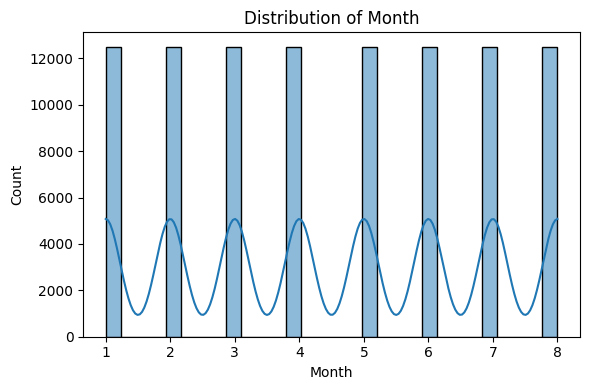

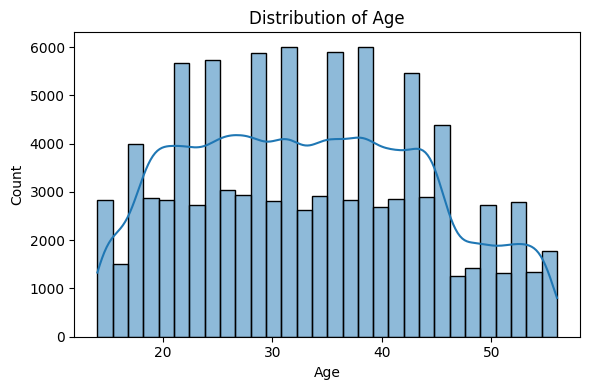

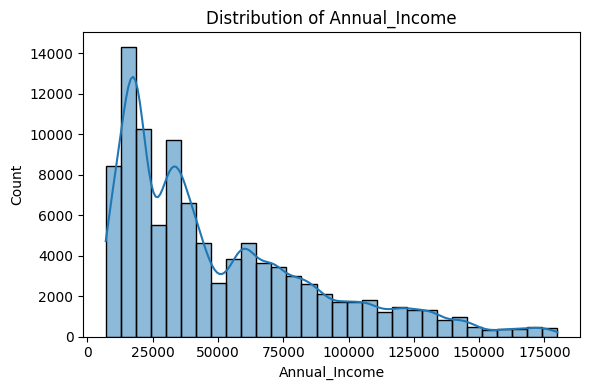

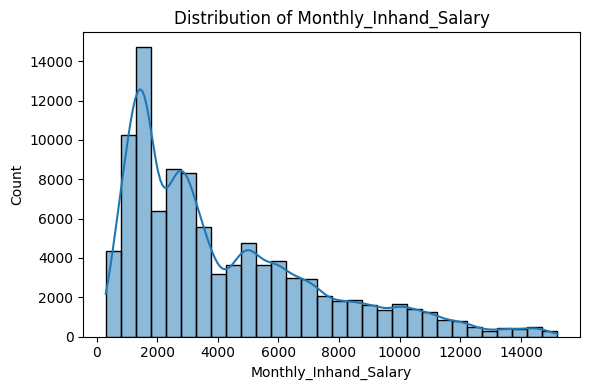

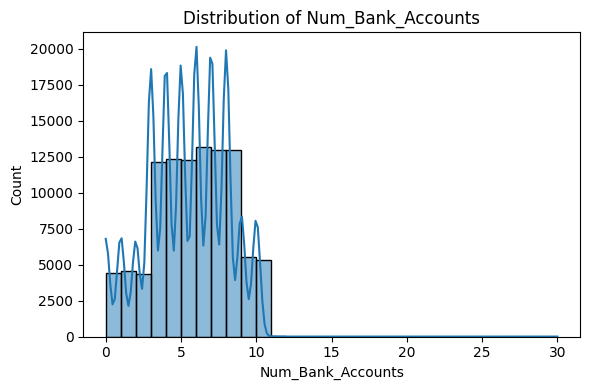

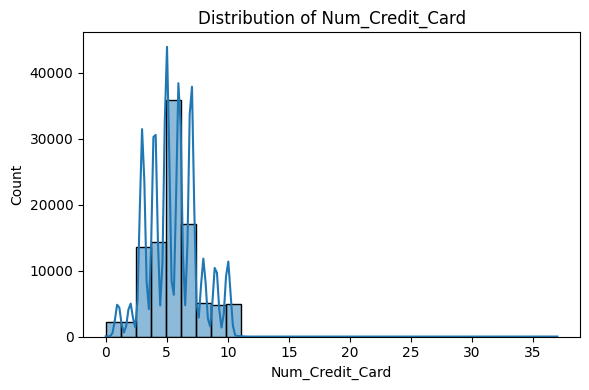

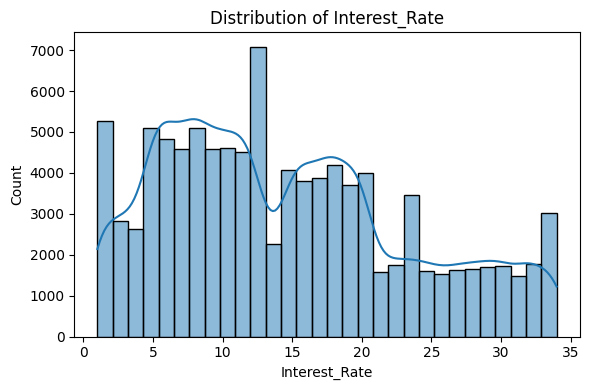

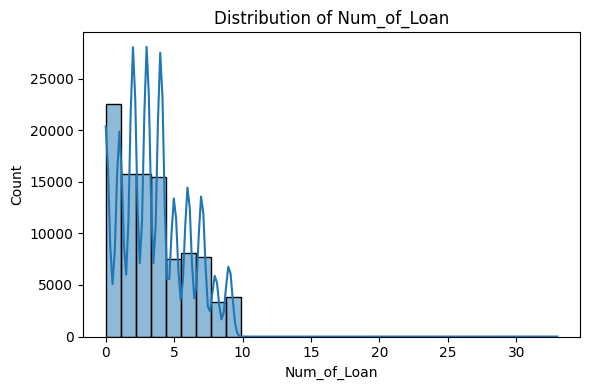

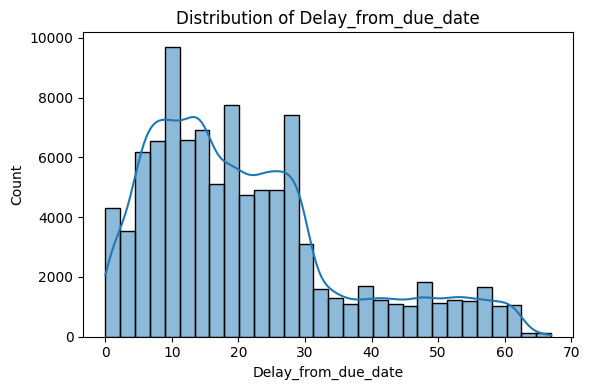

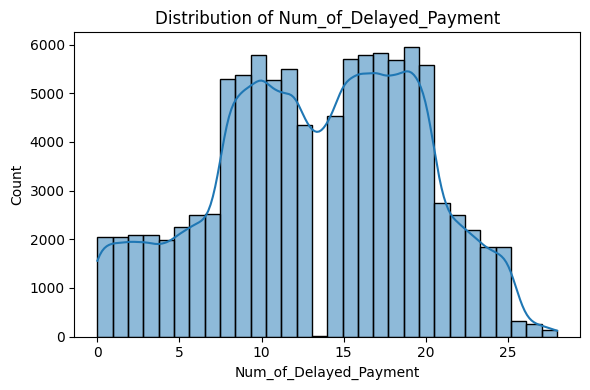

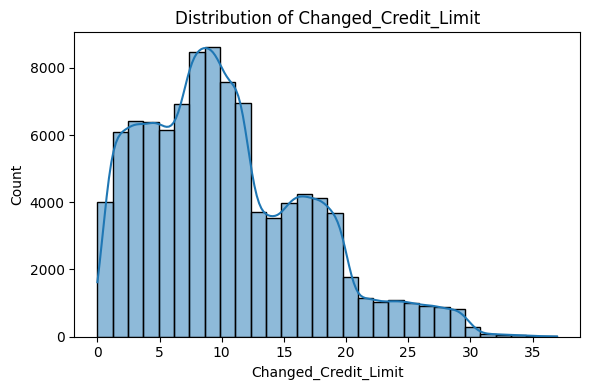

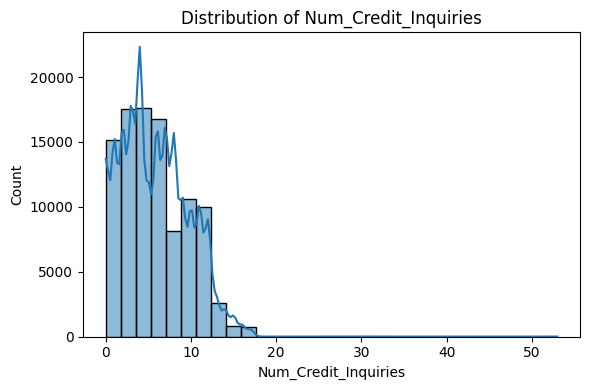

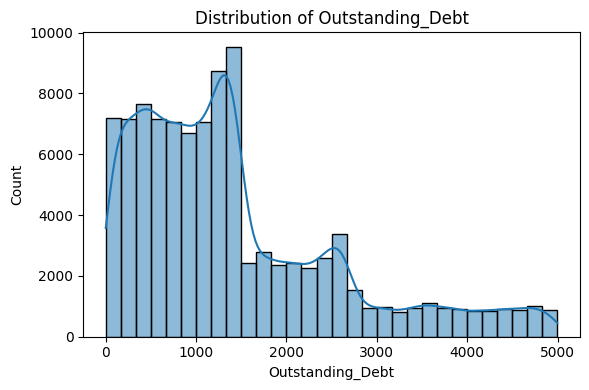

KeyboardInterrupt: 

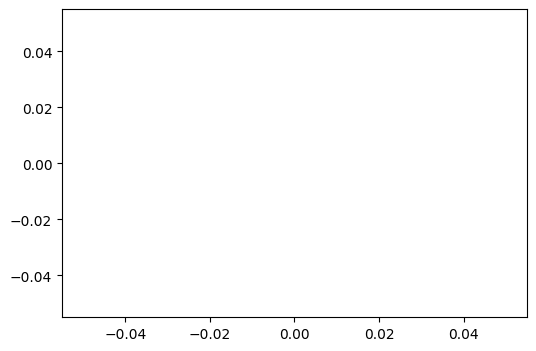

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(csc_df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

# For some of the columns logarithmic transformation might be usefull. Otherwise
# No more usefull actionable observations

In [ ]:
for col in num_cols:
    if col != 'Month':
        plt.figure(figsize=(6,4))
        sns.lineplot(x='Month', y=col, data=csc_df, estimator='mean')
        plt.title(f'Mean {col} by Month')
        plt.tight_layout()
        plt.show()

# From the Monthly graph we can see that the data doesnot vary much
# depending on the data which can be a good sign. From the corr and VIF
# or chi2 anova t-test whatever.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(7,4))

    for score in csc_df['Credit_Score'].unique():
        subset = csc_df[csc_df['Credit_Score'] == score]
        sns.kdeplot(subset[col], label=score, fill=True, alpha=0.3)

    plt.title(f'Distribution of {col} by Credit_Score')
    plt.legend(title='Credit_Score')
    plt.tight_layout()
    plt.show()
## From the distributions there are no actionable observations

In [ ]:
for col in ['Occupation','Credit_Mix','Payment_of_Min_Amount']:
    plt.figure(figsize=(7,4))
    csc_df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
for col in ['Occupation','Credit_Mix','Payment_of_Min_Amount']:
    plt.figure(figsize=(8,4))
    sns.countplot(data=csc_df, x=col, hue='Credit_Score')
    plt.title(f'{col} vs Credit_Score')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
csc_df[csc_df['Customer_ID']==10314]

In [ ]:
csc_df.isnull().sum()

In [ ]:
corr_matrix = csc_df[num_cols].corr(method='pearson')

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=False,
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.title("Correlation Matrix (Numerical Features)")
plt.tight_layout()
plt.show()

In [ ]:
# Optional: temporary imputation for VIF
X = csc_df[num_cols].copy()
X = X.fillna(X.median())

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data.sort_values(by="VIF", ascending=False)

# From the values we can see that some colums have higher multicolinearity
# they should be removed.

In [ ]:
while True:
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                       for i in range(X.shape[1])]

    max_vif = vif_data["VIF"].max()

    if max_vif > 5:
        drop_feature = vif_data.sort_values("VIF", ascending=False)["Feature"].iloc[0]
        print(f"Dropping {drop_feature} with VIF={max_vif}")
        X = X.drop(columns=[drop_feature])
    else:
        break

print("Final Features:")
print(X.columns)

## From the results we can see that on global data there is a possibility that
# this 4 columns should be removed as they have higher colinearity.

In [ ]:
from scipy.stats import chi2_contingency

for col in cat_cols:
    contingency_table = pd.crosstab(csc_df[col], csc_df[target_col[0]])

    chi, p, dof, expected = chi2_contingency(contingency_table)

    print(f"\nChi2 Test: {col} vs {target_col}")
    print(f"Chi2 Statistic: {chi:.4f}")
    print(f"P-value: {p:.6f}")
    print(f"Degrees of Freedom: {dof}")

In [ ]:
from scipy.stats import f_oneway

for col in num_cols:
    groups = [csc_df[csc_df[target_col[0]] == score][col].dropna()
              for score in csc_df[target_col[0]].unique()]

    stat, p = f_oneway(*groups)

    print(f"\nANOVA: {col} vs {target_col}")
    print(f"F-statistic: {stat:.4f}")
    print(f"P-value: {p:.6f}")

In [ ]:
csc_df.head()

In [ ]:
csc_df.info()

In [ ]:
csc_df.isnull().sum()

In [ ]:
# Things to tackle
# how to deal with loan column

In [5]:
num_cols = ['Age','Annual_Income','Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card',
            'Interest_Rate','Num_of_Loan','Delay_from_due_date','Num_of_Delayed_Payment','Changed_Credit_Limit',
         'Num_Credit_Inquiries','Outstanding_Debt','Credit_Utilization_Ratio','Credit_History_Age',
            'Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance']
cat_cols = ['Month','Occupation','Type_of_Loan','Credit_Mix','spent_behaviour','spent_value','Payment_of_Min_Amount']
target_col = ['Credit_Score']

In [6]:
from sklearn.model_selection import GroupShuffleSplit

X = csc_df.drop(columns=['Credit_Score'])
y = csc_df['Credit_Score']
groups = csc_df['Customer_ID']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_customers = set(X_train['Customer_ID'])
test_customers = set(X_test['Customer_ID'])

print("No of Common customers:", train_customers.intersection(test_customers))

print(y_train.value_counts()/y_train.shape[0])
print(y_test.value_counts()/y_test.shape[0])

No of Common customers: set()
Credit_Score
Standard    0.531875
Poor        0.289812
Good        0.178313
Name: count, dtype: float64
Credit_Score
Standard    0.53120
Poor        0.29065
Good        0.17815
Name: count, dtype: float64


In [13]:
X_train_imputed

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,spent_behaviour,spent_value
0,3392,1.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",3.0,7.0,11.27,4.0,Good,809.98,26.822620,265.0,No,49.574949,80.415295,312.494089,NaN,NaN
1,3392,2.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",3.0,6.5,11.27,4.0,Good,809.98,31.944960,266.0,No,49.574949,118.280222,284.629162,NaN,NaN
2,3392,3.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",3.0,7.0,11.27,4.0,Good,809.98,28.609352,267.0,No,49.574949,81.699521,331.209863,NaN,NaN
3,3392,4.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",5.0,4.0,6.27,4.0,Good,809.98,31.377862,268.0,No,49.574949,199.458074,223.451310,NaN,NaN
4,3392,5.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",6.0,6.5,11.27,4.0,Good,809.98,24.797347,269.0,No,49.574949,41.420153,341.489231,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99963,14124,4.0,18.0,Lawyer,42903.79,3468.315833,0.0,4.0,6.0,1.0,not specified,14.0,0.0,5.10,1.0,Good,1079.48,30.625298,340.0,No,34.975457,31.193919,520.662207,NaN,NaN
99964,14124,5.0,18.0,Lawyer,42903.79,3468.315833,0.0,4.0,6.0,1.0,not specified,14.0,0.0,5.10,1.0,Good,1079.48,23.140640,341.0,No,34.975457,450.646093,151.210033,NaN,NaN
99965,14124,6.0,19.0,Lawyer,42903.79,3468.315833,0.0,4.0,6.0,1.0,not specified,14.0,0.0,5.10,1.0,Good,1079.48,35.549456,342.0,No,34.975457,187.355969,394.500158,NaN,NaN
99966,14124,7.0,19.0,Lawyer,42903.79,3468.315833,0.0,4.0,6.0,1.0,not specified,14.0,0.0,5.10,1.0,Good,1079.48,35.123480,343.0,No,34.975457,240.873798,350.982329,NaN,NaN


In [10]:
loan_impute = cst.missingcategory(['Type_of_Loan'],'not specified')
X_train_imputed = loan_impute.transform(X_train)

X_train_imputed['spent_behaviour'] = X_train_imputed['spent_behaviour'].map({'High':1,'Low':0})
X_train_imputed['spent_value'] = X_train_imputed['spent_value'].map({'Small':1,'medium':2,'Large':3})

from sklearn.preprocessing import MultiLabelBinarizer


loan_types =['debt consolidation loan', 'student loan', 'auto loan',
       'credit-builder loan', 'mortgage loan', 'home equity loan',
       'personal loan', 'payday loan', 'not specified']
mlb1 = MultiLabelBinarizer(classes=loan_types)

mlb1_df = pd.DataFrame(
    mlb1.fit_transform(X_train_imputed['Type_of_Loan']),
    columns=mlb1.classes_,
    index=X_train_imputed.index
)


ohe = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
ohe_df1 = ohe.fit_transform(X_train_imputed[['Occupation']])

X_train_mlb = pd.concat([X_train_imputed,mlb1_df,ohe_df1],axis=1)

dropper = cst.drop_columns(columns_to_drop=['Type_of_Loan','Occupation'])

X_train_mlb = dropper.transform(X_train_mlb)

from sklearn.preprocessing import OrdinalEncoder

ord = OrdinalEncoder(categories=[['Bad', 'Standard', 'Good']])

X_train_mlb[['Credit_Mix']] = ord.fit_transform(X_train_mlb[['Credit_Mix']])
X_train_mlb['Payment_of_Min_Amount'] = X_train_mlb['Payment_of_Min_Amount'].map({'Yes':1,'No':0})


/content/drive/MyDrive/credit_score_project/my_module/custom_transformers.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[self.columns_to_fill] = X[self.columns_to_fill].fillna(self.missing_label)
/tmp/ipykernel_311/777873487.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_imputed['spent_behaviour'] = X_train_imputed['spent_behaviour'].map({'High':1,'Low':0})
/tmp/ipykernel_311/777873487.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

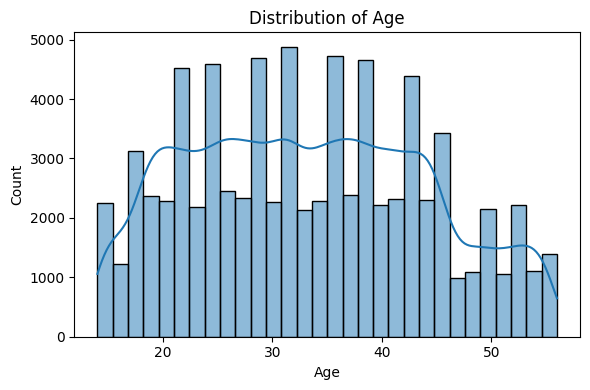

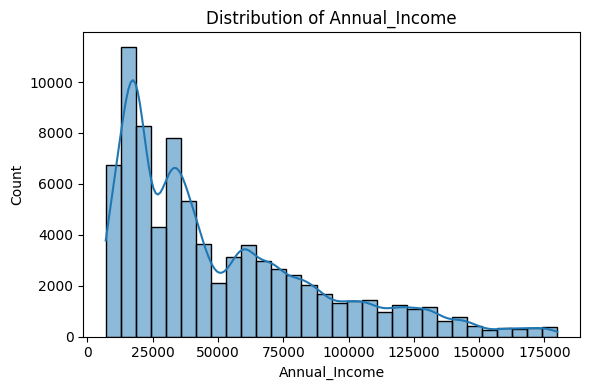

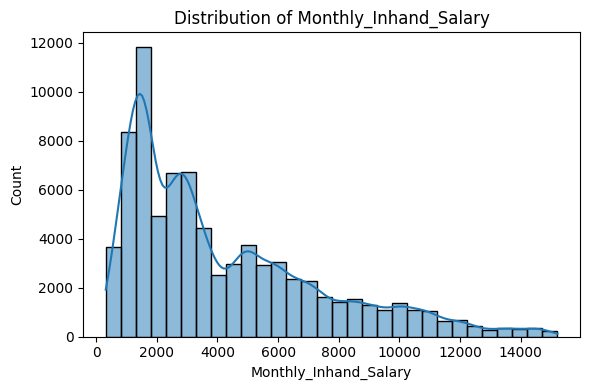

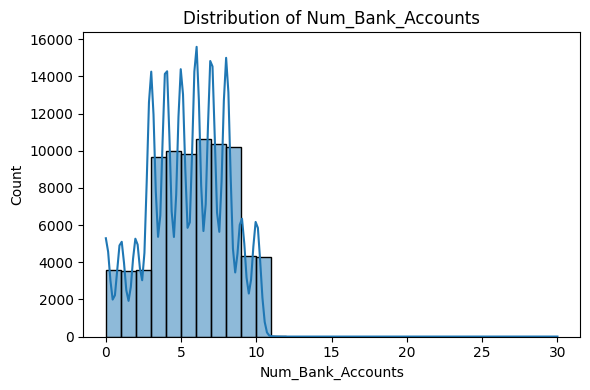

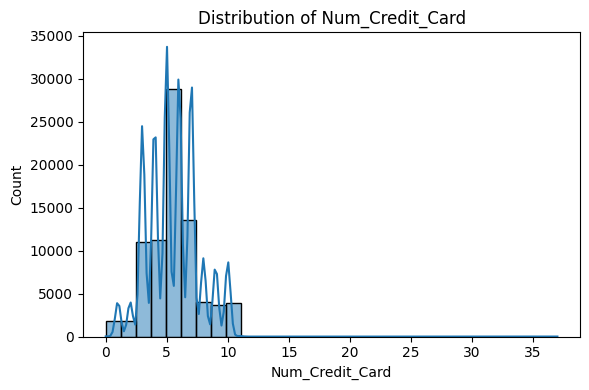

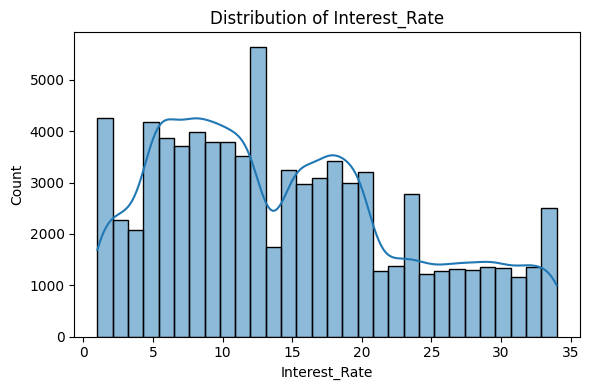

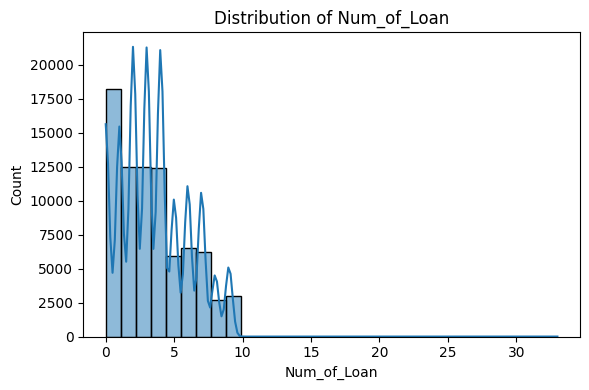

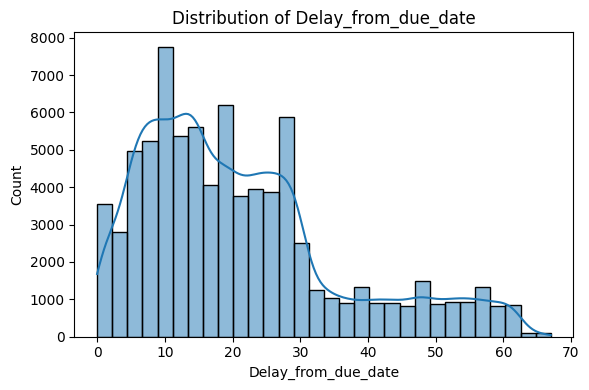

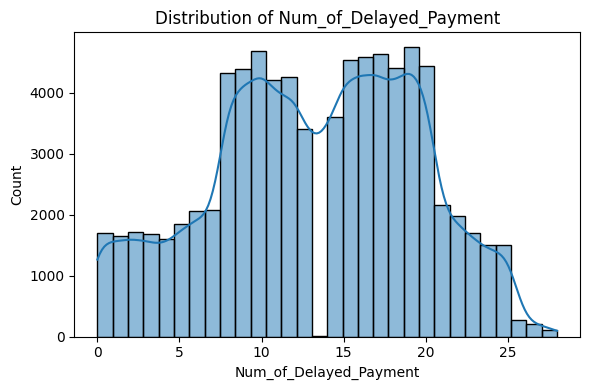

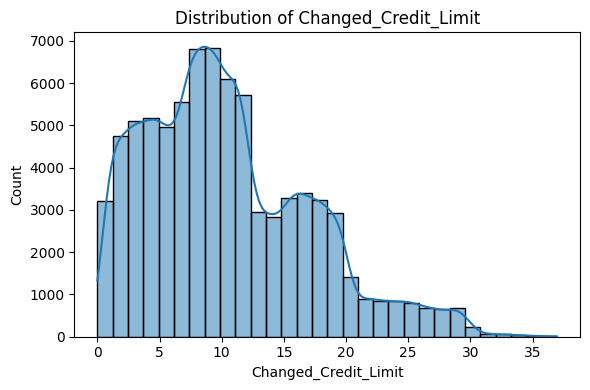

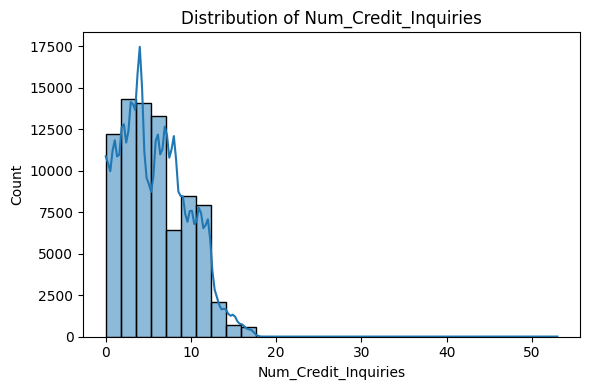

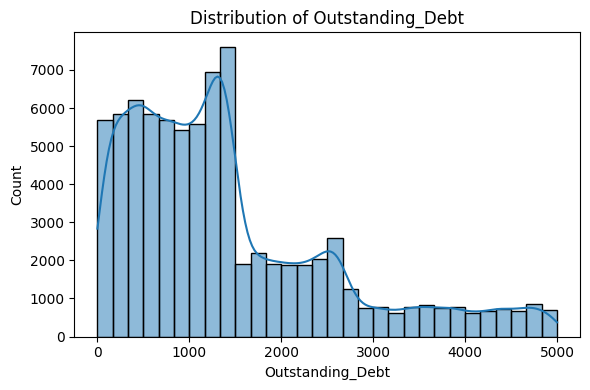

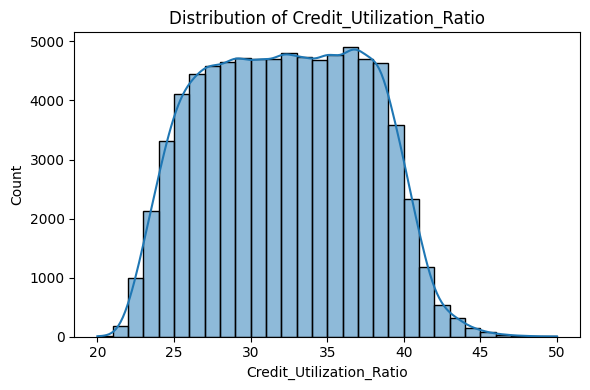

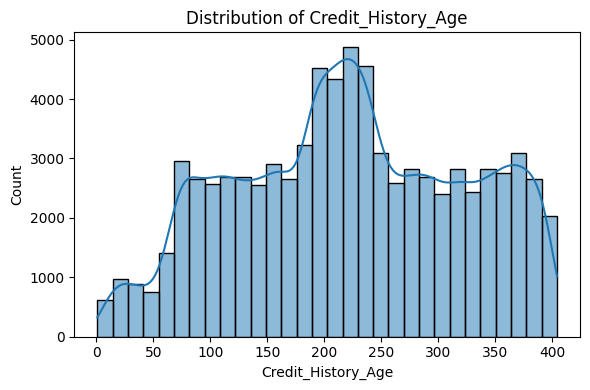

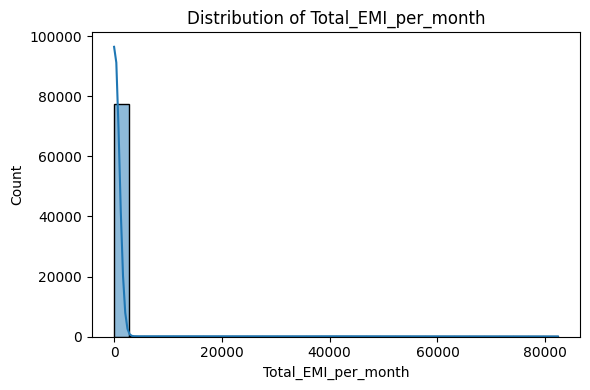

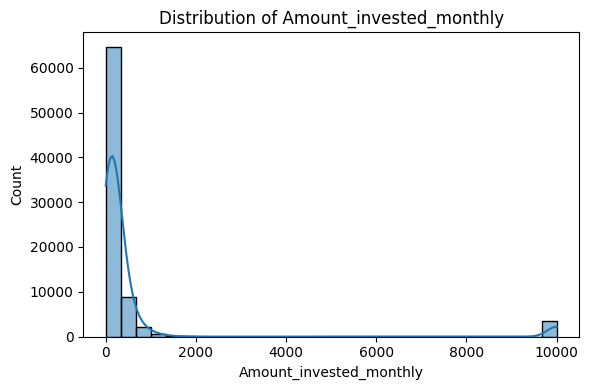

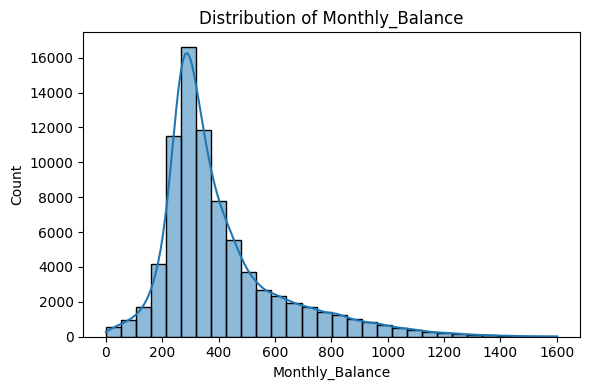

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(X_train[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

# For some of the columns logarithmic transformation might be usefull. Otherwise
# No more usefull actionable observations

In [14]:
# from sklearn.compose import ColumnTransformer

# from sklearn.base import BaseEstimator, TransformerMixin

# from sklearn.base import BaseEstimator, TransformerMixin
# from sklearn.preprocessing import MultiLabelBinarizer
# from sklearn.preprocessing import LabelEncoder
# import pandas as pd
from sklearn.preprocessing import FunctionTransformer
import numpy as np

loan_types =['debt consolidation loan', 'student loan', 'auto loan',
       'credit-builder loan', 'mortgage loan', 'home equity loan',
       'personal loan', 'payday loan', 'not specified']

loan_impute = cst.missingcategory(['Type_of_Loan'],'not specified')
mlb = cst.MultiLabelBinarizerCustom(loan_types=loan_types)
ohe = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
ord_credit_mix = OrdinalEncoder(categories=[['Bad', 'Standard', 'Good']])
ord_spent_value = OrdinalEncoder(categories=[['Small','Medium','Large']])
binary_payment = OrdinalEncoder(categories=[['No','Yes']])
binary_spent_behaviour = OrdinalEncoder(categories=[['Low','High']])

encoder = ColumnTransformer(transformers = [
    ('loan_type',mlb,['Type_of_Loan']),
    ('ohe',ohe,['Occupation']),
    ('ord_credit_mix',ord_credit_mix,['Credit_Mix']),
    ('ord_spent_value',ord_spent_value,['spent_value']),
    ('binary_amount',binary_payment,['Payment_of_Min_Amount']),
    ('binary_spent_behaviour',binary_spent_behaviour,['spent_behaviour']),

],remainder='passthrough')

from sklearn.pipeline import Pipeline

cat_pipeline = Pipeline(steps=[
    ('loan_imputer',loan_impute),
     ('encoder',encoder),
    ('renamer',cst.renamer())
])

skew_transformer = ColumnTransformer(transformers=[
    ('skewed_cols',FunctionTransformer(func=np.log1p,validate=False),['Monthly_Balance','Amount_invested_monthly','Total_EMI_per_month','Outstanding_Debt',
               'Num_of_Loan','Monthly_Inhand_Salary','Annual_Income'])
],remainder='passthrough')

num_pipeline = Pipeline(steps=[
    ("log_transform",skew_transformer),
    ("std_Scaler",StandardScaler()),
    ('renamer',cst.renamer())
])

preprocess_pipeline = ColumnTransformer(transformers=[
    ('categorical',cat_pipeline,['Month','Occupation','Type_of_Loan','Credit_Mix','spent_behaviour','spent_value','Payment_of_Min_Amount']),
    ('numerical',num_pipeline,['Age','Annual_Income','Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card',
            'Interest_Rate','Num_of_Loan','Delay_from_due_date','Num_of_Delayed_Payment','Changed_Credit_Limit',
         'Num_Credit_Inquiries','Outstanding_Debt','Credit_Utilization_Ratio','Credit_History_Age',
            'Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance'])
])

In [15]:
preprocess_pipeline
# import joblib
# joblib.dump(preprocess_pipeline,'/content/drive/MyDrive/credit_score_project/preprocessing/csc_preprocess_v1.joblib')

ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('loan_imputer',
                                                  missingcategory(columns_to_fill=['Type_of_Loan'],
                                                                  missing_label='not '
                                                                                'specified')),
                                                 ('encoder',
                                                  ColumnTransformer(remainder='passthrough',
                                                                    transformers=[('loan_type',
                                                                                   MultiLabelBinarizerCustom(loan_types=['debt '
                                                                                                                         'consolidation '
                                                                                                                         'loan',
                                                                                                                         'student '
                                                                                                                         'loan',
                                                                                                                         'auto '
                                                                                                                         'loan',
                                                                                                                         'credit-builde...
                                                 ('renamer', renamer())]),
                                 ['Age', 'Annual_Income',
                                  'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
                                  'Num_Credit_Card', 'Interest_Rate',
                                  'Num_of_Loan', 'Delay_from_due_date',
                                  'Num_of_Delayed_Payment',
                                  'Changed_Credit_Limit',
                                  'Num_Credit_Inquiries', 'Outstanding_Debt',
                                  'Credit_Utilization_Ratio',
                                  'Credit_History_Age', 'Total_EMI_per_month',
                                  'Amount_invested_monthly',
                                  'Monthly_Balance'])])

In [16]:
preprocessed = preprocess_pipeline.fit_transform(X_train)

Index(['Type_of_Loan'], dtype='object')


ValueError: could not convert string to float: 'Small'

In [ ]:
preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 0 to 99967
Data columns (total 46 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   categorical__debt consolidation loan   80000 non-null  int64  
 1   categorical__student loan              80000 non-null  int64  
 2   categorical__auto loan                 80000 non-null  int64  
 3   categorical__credit-builder loan       80000 non-null  int64  
 4   categorical__mortgage loan             80000 non-null  int64  
 5   categorical__home equity loan          80000 non-null  int64  
 6   categorical__personal loan             80000 non-null  int64  
 7   categorical__payday loan               80000 non-null  int64  
 8   categorical__not specified             80000 non-null  int64  
 9   categorical__Occupation_Accountant     80000 non-null  float64
 10  categorical__Occupation_Architect      80000 non-null  float64
 11  categor